 Exploratory Data Analysis (EDA) - Used Cars Dataset
Supervised by: Dr. Mustafa Al-Youssef
Student Name: [Aber Hamoud Abd]  
Course: Big Data Analysis  
Dataset Source: Kaggle - Used Cars Dataset  

 Project Overview
This project presents an exploratory data analysis on a used cars dataset. The primary objective is to inspect, clean, visualize, and analyze key variables affecting used car pricing, mileage, and feature distributions.

Research Questions
1. What is the distribution of car selling prices and manufacturing years?
2. How does the manufacturing year impact the selling price?
3. What is the relationship between kilometers driven (mileage) and selling price?
4. How do categorical features (e.g., fuel type, transmission type) influence the price?

Section B: Load and Inspect the Data

In this section, we import the required Python libraries for data processing and visualization:
- pandas: For data manipulation and tabular analysis.
- numpy: For numerical operations.
- matplotlib & seaborn: For creating customized statistical graphics.

We then load the dataset using a relative file path (dataset.csv) and inspect its structural properties such as shape, sample rows, column types, and basic statistic

1. Import Required Libraries
In this step, we import essential Python libraries: Pandas for data manipulation, NumPy for numerical operations, and Matplotlib/Seaborn for data visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

2. Load the Dataset
We load the dataset using a relative file path (dataset.csv) and display the first 5 rows to understand its structure

In [2]:
df = pd.read_csv("dataset.csv")
display(df.head())

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,24-Nov,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,24-Jul,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,24-Nov,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,24-Nov,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,24-Nov,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


3. Inspect Dataset Shape and Info
Here we print the total number of rows and columns, as well as the column data types and non-null value counts

In [3]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.info()

Dataset Shape: 9582 rows, 11 columns
<class 'pandas.DataFrame'>
RangeIndex: 9582 entries, 0 to 9581
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Brand         9582 non-null   str  
 1   model         9582 non-null   str  
 2   Year          9582 non-null   int64
 3   Age           9582 non-null   int64
 4   kmDriven      9535 non-null   str  
 5   Transmission  9582 non-null   str  
 6   Owner         9582 non-null   str  
 7   FuelType      9582 non-null   str  
 8   PostedDate    9582 non-null   str  
 9   AdditionInfo  9582 non-null   str  
 10  AskPrice      9582 non-null   str  
dtypes: int64(2), str(9)
memory usage: 1.8 MB


4. Summary Statistics
This step generates descriptive statistics for all numerical columns, including count, mean, standard deviation, min, and max values

In [4]:
display(df.describe())

,Year,Age
count,9582.000000,9582.000000
mean,2016.361094,7.638906
std,4.087226,4.087226
min,1986.000000,0.000000
25%,2014.000000,5.000000
50%,2017.000000,7.000000
75%,2019.000000,10.000000
max,2024.000000,38.000000


Section C: Check and Prepare the Data

In this section, we check for missing values and duplicate rows, clean string formatting from numeric columns (AskPrice and kmDriven), and convert them to proper numeric data types for analysis

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows count:", df.duplicated().sum())

Missing values per column:
Brand            0
model            0
Year             0
Age              0
kmDriven        47
Transmission     0
Owner            0
FuelType         0
PostedDate       0
AdditionInfo     0
AskPrice         0
dtype: int64

Duplicate rows count: 724


Data Cleaning and Type Conversion
We clean currency and distance characters from AskPrice and kmDriven columns and convert them to numeric types so we can analyze them statistically

In [6]:
df['AskPrice'] = df['AskPrice'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['AskPrice'] = pd.to_numeric(df['AskPrice'], errors='coerce')

df['kmDriven'] = df['kmDriven'].astype(str).str.replace(r'[^\d.]', '', regex=True)
df['kmDriven'] = pd.to_numeric(df['kmDriven'], errors='coerce')

df.dropna(subset=['AskPrice', 'kmDriven'], inplace=True)

display(df.describe())

,Year,Age,kmDriven,AskPrice
count,9535.000000,9535.000000,9535.000000,9.535000e+03
mean,2016.375669,7.624331,70605.891453,1.067161e+06
std,4.071090,4.071090,56308.596299,1.661675e+06
min,1986.000000,0.000000,0.000000,1.500000e+04
25%,2014.000000,5.000000,43000.000000,3.650000e+05
50%,2017.000000,7.000000,65000.000000,5.999990e+05
75%,2019.000000,10.000000,86000.000000,1.140000e+06
max,2024.000000,38.000000,980002.000000,4.250000e+07


Section D: Describe and Visualize the Data
 1. Distribution of Car Prices (Histogram)
We plot a histogram to examine the distribution and frequency of car prices (AskPrice). This helps identify skewness and common price ranges.

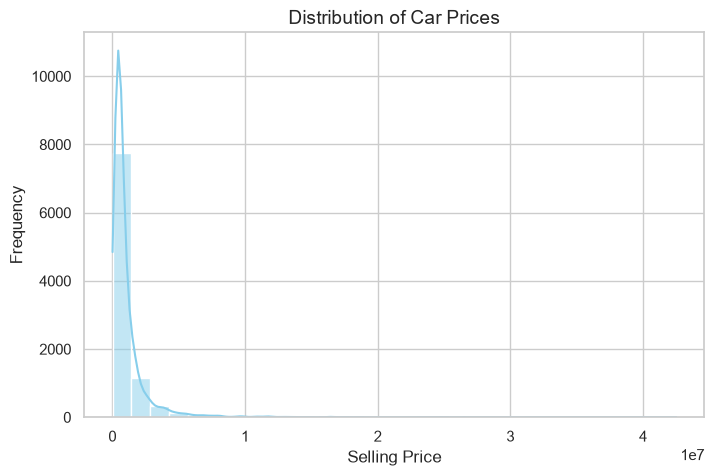

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['AskPrice'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Car Prices', fontsize=14)
plt.xlabel('Selling Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Explanation of Price Distribution
The histogram reveals that car prices are right-skewed, meaning the majority of used cars are priced in the lower to mid-range, with a few high-priced outliers

 2. Kilometers Driven Spread and Outliers (Box Plot)
A box plot is used to analyze the spread, median, and potential outliers in total kilometers driven (kmDriven).

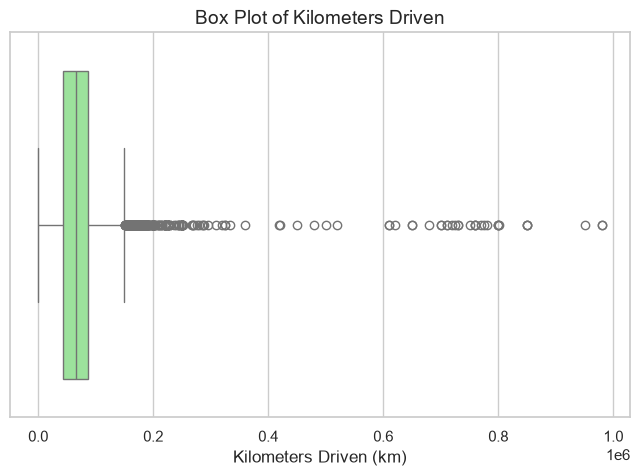

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['kmDriven'], color='lightgreen')
plt.title('Box Plot of Kilometers Driven', fontsize=14)
plt.xlabel('Kilometers Driven (km)', fontsize=12)
plt.show()

 Explanation of Box Plot
The box plot shows the median mileage and highlights upper outliers representing vehicles with exceptionally high mileage compared to the rest of the dataset

3. Comparison of Cars by Fuel Type (Bar Chart)
We create a bar chart to compare the count and proportion of used cars across different fuel types (FuelType)

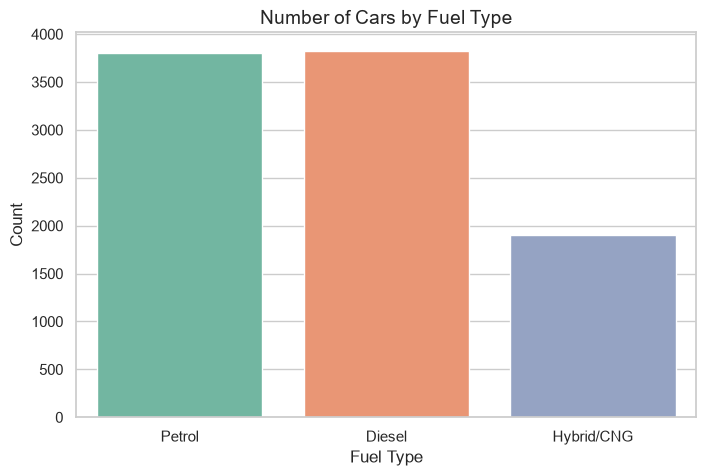

In [9]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(8, 5))
sns.countplot(x='FuelType', data=df, hue='FuelType', legend=False, palette='Set2')
plt.title('Number of Cars by Fuel Type', fontsize=14)
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

Explanation of Fuel Type Comparison
The bar chart illustrates the categorical distribution of fuel types in the dataset, showing which fuel type is most dominant among sellers.

1. Correlation Heatmap
We construct a correlation heatmap to measure the strength and direction of linear relationships between numerical attributes

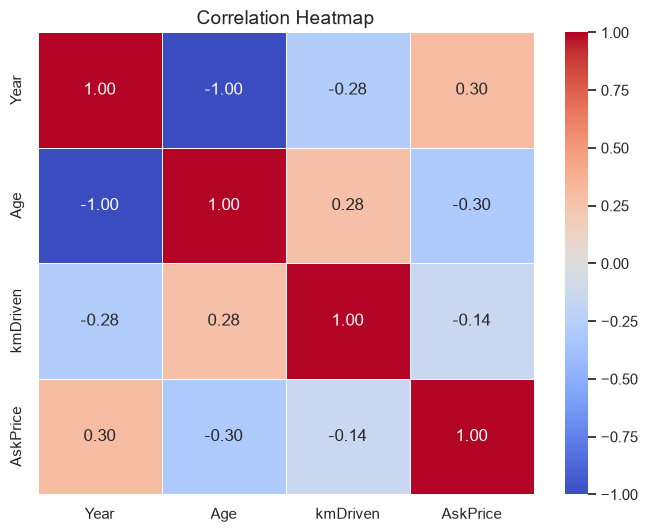

In [10]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

Explanation of Correlation Heatmap
The heatmap indicates that vehicle age has a negative correlation with selling price, meaning older cars generally sell for lower prices. On the other hand, the manufacturing year correlates positively with price

2. Relationship Between Kilometers Driven and Price (Scatter Plot)
We use a scatter plot to visualize how mileage (kmDriven) impacts car pricing (AskPrice)

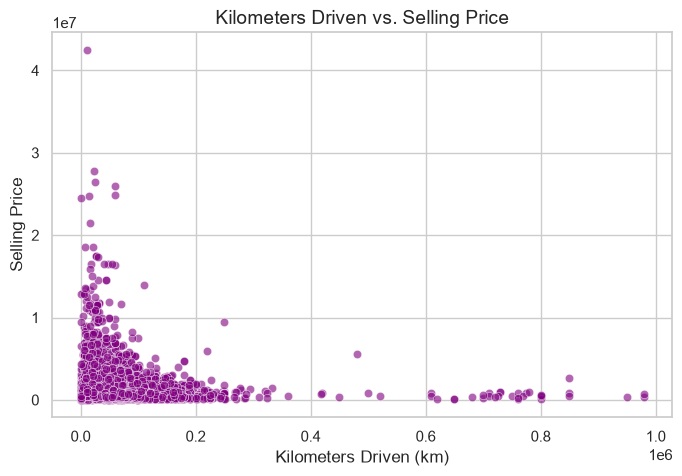

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='kmDriven', y='AskPrice', data=df, alpha=0.6, color='purple')
plt.title('Kilometers Driven vs. Selling Price', fontsize=14)
plt.xlabel('Kilometers Driven (km)', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.show()

Explanation of Scatter Plot
The scatter plot demonstrates an inverse relationship where cars with lower mileage tend to fetch significantly higher market prices, while high-mileage cars cluster at lower price levels

Section F: Conclusions and Final Insights

In this final section, we summarize the main insights derived from the Exploratory Data Analysis (EDA) of the used cars dataset and answer our initial research questions

Summary of Key Findings:
1. Price Distribution: Used car prices are right-skewed, showing that most listed vehicles are budget to mid-range cars, with a few luxury or high-end exceptions.
2. Impact of Mileage: There is a clear negative relationship between kilometers driven (kmDriven) and price (AskPrice). Vehicles with lower mileage retain significantly higher value.
3. Age & Depreciation: Vehicle age strongly influences resale value. Newer models command higher prices, while price drops noticeably as the car ages beyond 5–7 years.
4. Fuel & Transmission: Fuel type and transmission choices show clear preferences in the market, directly influencing supply and pricing dynamics.
 Final Conclusion
This EDA successfully answered all primary research questions, validated the data through cleaning and numerical conversions, and provided structured insights into the used car market pricing factors.